In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [3]:
import numpy as np

In [4]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


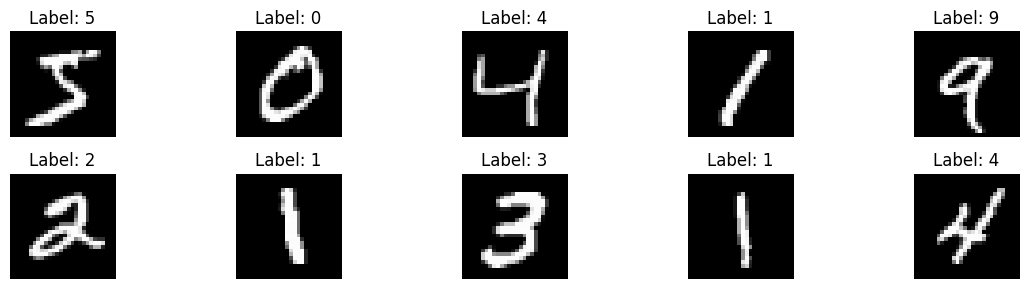

In [5]:
# visualizing some digits from the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
train_images.shape

(60000, 28, 28)

In [17]:
# flattening the images to train our model
X_train = train_images.reshape(60000,784).T
Y_train = train_labels
X_train.shape

(784, 60000)

In [48]:
Y_labels = Y_train                 
Y = np.eye(10)[Y_labels].T 

In [107]:
X_small = X_train[:, :10000]
Y_small = Y[:, :10000]
Y_labels_small = Y_labels[:10000]

In [108]:
class Layer_dense:
    def __init__(self,inputs,neurons):
        self.weights = np.random.randn(neurons,inputs) * 0.01
        self.biases = np.zeros((neurons,1))
    def forward(self,x):
        self.x = x
        self.output = (self.weights @ x) + self.biases
        return self.output
    
class RelU:
    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.maximum(0,inputs)
        return self.output
    
class Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs,axis=0,keepdims=True))
        probabilities = exp_values/np.sum(exp_values,axis=0,keepdims=True)
        self.output = probabilities
        return self.output
    
class Loss:
    def forward(self,y_pred,y_true):
        samples = y_pred.shape[1]
        if y_true.ndim == 2:
            y_true = np.argmax(y_true, axis=0)
        correct_confidence = y_pred[y_true,np.arange(samples)]
        correct_confidence = np.clip(
            correct_confidence,
            1e-7,
            1 - 1e-7
        )
        loss = -np.log(correct_confidence)
        return np.mean(loss)

In [109]:
layer_1 = Layer_dense(784,128)
layer_2 = Layer_dense(128,10)
relu_actv = RelU()
softmax_actv = Softmax()
loss_function= Loss()

In [110]:
print("X_train:", X_train.shape)
print("layer_1.weights:", layer_1.weights.shape)
print("layer_1.bias:", layer_1.bias.shape if hasattr(layer_1, "bias") else layer_1.biases.shape)

X_train: (784, 60000)
layer_1.weights: (128, 784)
layer_1.bias: (128, 1)


In [111]:
# training loop
learning_rate = 0.005
epochs = 1000

accuracy_dict = {
    "accuracy": [],
    "w1": [],
    "w2": [],
    "b1": [],
    "b2": []
}


for epoch in range(epochs):

    #initiallizations
    inputs = X_small
    output1 = relu_actv.forward(layer_1.forward(inputs))
    output2 = softmax_actv.forward(layer_2.forward(output1))

    predictions = output2

    #loss
    loss = loss_function.forward(predictions,Y_small)

    #accuracy
    predicted_class = np.argmax(predictions,axis=0)
    accuracy = np.mean(predicted_class==Y_labels_small)


    #backpropagation
    m = X_train.shape[1]
    dz2 = predictions - Y_small

    dw2 = (1/m) * (dz2 @ output1.T)
    db2 = (1/m) * np.sum(dz2,axis=1,keepdims=True)

    da1 = layer_2.weights.T @ dz2

    dz1 = da1.copy()
    dz1[relu_actv.inputs <= 0 ] = 0

    dw1 = (1/m) * (dz1 @ inputs.T)
    db1 = (1/m) * np.sum(dz1,axis=1,keepdims=True)

    # updating weights and biases by gradient descent
    layer_1.weights -= learning_rate * dw1
    layer_1.biases -= learning_rate * db1

    layer_2.weights -= learning_rate * dw2
    layer_2.biases -= learning_rate * db2

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch}, "
            f"Loss: {loss:.4f}, "
            f"Accuracy: {accuracy:.4f}"
        )
    accuracy_dict["accuracy"].append(accuracy)

    accuracy_dict["w1"].append(layer_1.weights.copy())
    accuracy_dict["w2"].append(layer_2.weights.copy())

    accuracy_dict["b1"].append(layer_1.biases.copy())
    accuracy_dict["b2"].append(layer_2.biases.copy())


Epoch: 0, Loss: 4.1523, Accuracy: 0.0610
Epoch: 100, Loss: 0.3440, Accuracy: 0.9002
Epoch: 200, Loss: 0.2596, Accuracy: 0.9274
Epoch: 300, Loss: 0.2142, Accuracy: 0.9394
Epoch: 400, Loss: 0.1825, Accuracy: 0.9485
Epoch: 500, Loss: 0.1584, Accuracy: 0.9561
Epoch: 600, Loss: 0.1389, Accuracy: 0.9623
Epoch: 700, Loss: 0.1226, Accuracy: 0.9674
Epoch: 800, Loss: 0.1088, Accuracy: 0.9722
Epoch: 900, Loss: 0.0970, Accuracy: 0.9758


In [112]:
best_epoch = np.argmax(accuracy_dict["accuracy"])
best_accuracy = accuracy_dict["accuracy"][best_epoch]

print(f"Best Epoch: {best_epoch}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best Epoch: 998
Best Accuracy: 0.9790


In [113]:
best_W1 = accuracy_dict["w1"][best_epoch]
best_W2 = accuracy_dict["w2"][best_epoch]

best_b1 = accuracy_dict["b1"][best_epoch]
best_b2 = accuracy_dict["b2"][best_epoch]

layer_1.weights = best_W1.copy()
layer_1.biases = best_b1.copy()

layer_2.weights = best_W2.copy()
layer_2.biases = best_b2.copy()

In [114]:
X_test = test_images.reshape(10000, 784).T 

Y_test_labels = test_labels
Y_test = np.eye(10)[Y_test_labels].T

In [115]:
output1 = relu_actv.forward(layer_1.forward(X_test))
output2 = softmax_actv.forward(layer_2.forward(output1))

predictions = output2
predicted_class = np.argmax(predictions, axis=0)

test_accuracy = np.mean(predicted_class == Y_test_labels)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9370


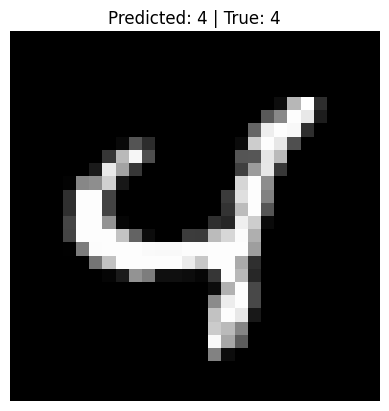

In [116]:
# predicting an image from the test dataset
index = int(input("Enter an index: "))

plt.imshow(test_images[index], cmap="gray")
plt.axis("off")

x = test_images[index].reshape(784, 1) / 255.0

output1 = relu_actv.forward(layer_1.forward(x))
output2 = softmax_actv.forward(layer_2.forward(output1))

predicted_digit = np.argmax(output2, axis=0)[0]

true_digit = test_labels[index]

plt.title(f"Predicted: {predicted_digit} | True: {true_digit}")
plt.show()

In [117]:
np.savez(
    "mnist_model.npz",
    W1=layer_1.weights,
    b1=layer_1.biases,
    W2=layer_2.weights,
    b2=layer_2.biases,
    hidden_neurons=128,
    learning_rate=learning_rate,
    epochs=epochs,
    best_accuracy=best_accuracy
)
print("Model saved successfully!")

Model saved successfully!


In [118]:
model = np.load("mnist_model.npz")
W1 = model["W1"]
b1 = model["b1"]

W2 = model["W2"]
b2 = model["b2"]

hidden_neurons = int(model["hidden_neurons"])
learning_rate = float(model["learning_rate"])
epochs = int(model["epochs"])
best_accuracy = float(model["best_accuracy"])

print(hidden_neurons)
print(learning_rate)
print(epochs)
print(best_accuracy)

128
0.005
1000
0.979


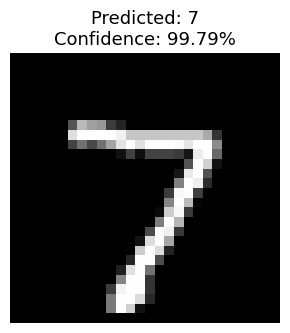

In [132]:
from PIL import Image
test_image = "mnist_test.png"
img = Image.open(test_image).convert("L")
img_array = np.array(img)
x = np.array(img).reshape(784, 1)

layer_1.weights = W1
layer_1.biases = b1

layer_2.weights = W2
layer_2.biases = b2

output_1 = relu_actv.forward(layer_1.forward(x))
probabilities = softmax_actv.forward(layer_2.forward(output_1))
predicted_digit = np.argmax(probabilities)
confidence = np.max(probabilities)

plt.figure(figsize=(3, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_digit}\nConfidence: {confidence*100:.2f}%", fontsize=13)
plt.tight_layout()
plt.show()